# Hough transform and Lane Detection 

In [32]:
import cv2
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt


In [33]:
def region_of_interest(img, vertices):
    mask = np.zeros_like(img)
    cv2.fillPoly(mask, vertices, 255)
    masked_img = cv2.bitwise_and(img, mask)
    return masked_img



In [34]:
def draw_lines(img,lines):
    if lines is None:
        return
    for line in lines:
        for x1 , y1 , x2 , y2 in line:
            cv2.line(img,(x1,y1),(x2,y2),(0,255,0),10)

In [35]:
def process_image(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (5,5), 0)
    edges = cv2.Canny(blur, 50, 150)


    height,width = image.shape[:2]
    region_of_interest_vertices = [
        (0, height),
        (width/2, height/2),
        (width, height)
    ]
    cropped_edges = region_of_interest(edges, np.array([region_of_interest_vertices], np.int32))
    lines = cv2.HoughLinesP(
        cropped_edges,
        rho=1,
        theta=np.pi/180,
        threshold=100,
        lines=np.array([]),
        minLineLength=40,
        maxLineGap=100
    )
    line_img = np.zeros_like(image)
    draw_lines(line_img, lines)
    combined_image = cv2.addWeighted(image, 0.8, line_img, 1.0, 0.0)
    return combined_image



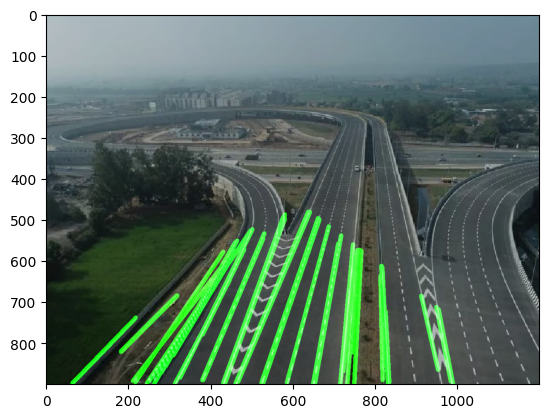

In [36]:
# load image files 
image = cv2.imread('test.jpg')

# check if the image was loaded properly
if image is None:
	print("Error: Could not load image.")
else:
	processed_image = process_image(image)
	plt.imshow(cv2.cvtColor(processed_image, cv2.COLOR_BGR2RGB))
	plt.show()

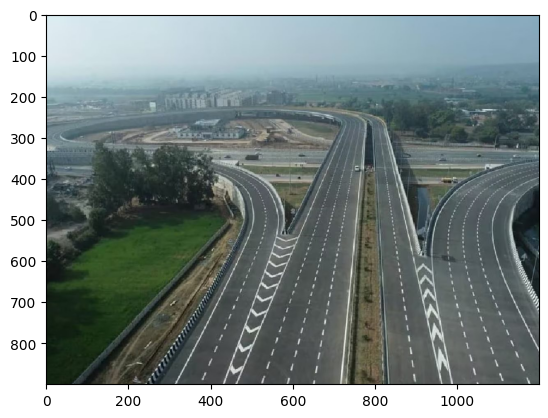

In [37]:
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.show()